In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 128
latent_dim = 128
learning_rate = 1e-3
epochs = 20

Using device: cpu


In [ ]:
data_path = './tiny-imagenet-10/train' 
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=data_path, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f"Loaded {len(train_dataset)} images.")
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")

Loaded 3500 images.
Batch shape: torch.Size([128, 3, 64, 64])


In [10]:
import os

print("Current working directory:", os.getcwd())
print("Exists?", os.path.exists('./tiny-imagenet-10/train'))

Current working directory: c:\Users\mohak\OneDrive\Desktop\dl ass
Exists? True


In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        
        self.flatten_size = 256 * 4 * 4
        
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = x.view(-1, self.flatten_size)
        
        mu = self.fc_mu(x)
        log_var = self.fc_logvar(x)
        return mu, log_var

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)
        
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = F.relu(self.deconv3(x))
        x = torch.sigmoid(self.deconv4(x)) 
        return x

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        reconstructed_x = self.decoder(z)
        return reconstructed_x, mu, log_var

model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
def vae_loss(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return BCE + KLD, BCE, KLD

model.train()

for epoch in range(epochs):
    total_loss = 0
    total_bce = 0
    total_kld = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        optimizer.zero_grad()
        
        recon_batch, mu, log_var = model(data)
        loss, bce, kld = vae_loss(recon_batch, data, mu, log_var)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()
        
    avg_loss = total_loss / len(train_loader.dataset)
    avg_bce = total_bce / len(train_loader.dataset)
    avg_kld = total_kld / len(train_loader.dataset)
    
    print(f'Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.2f} | BCE: {avg_bce:.2f} | KLD: {avg_kld:.2f}')

torch.save(model.state_dict(), 'vae_tiny_imagenet.pth')
print("Model saved. Now you can actually do Part 2.")

Epoch [1/20] | Loss: 8284.75 | BCE: 8278.21 | KLD: 6.54
Epoch [2/20] | Loss: 8019.73 | BCE: 7996.61 | KLD: 23.12
Epoch [3/20] | Loss: 7784.98 | BCE: 7748.97 | KLD: 36.01
Epoch [4/20] | Loss: 7573.16 | BCE: 7520.80 | KLD: 52.36
Epoch [5/20] | Loss: 7480.70 | BCE: 7422.39 | KLD: 58.31
Epoch [6/20] | Loss: 7374.25 | BCE: 7307.85 | KLD: 66.40
Epoch [7/20] | Loss: 7313.67 | BCE: 7245.80 | KLD: 67.87
Epoch [8/20] | Loss: 7275.60 | BCE: 7204.40 | KLD: 71.20
Epoch [9/20] | Loss: 7247.33 | BCE: 7176.05 | KLD: 71.28
Epoch [10/20] | Loss: 7220.51 | BCE: 7148.63 | KLD: 71.88
Epoch [11/20] | Loss: 7200.20 | BCE: 7129.02 | KLD: 71.18
Epoch [12/20] | Loss: 7185.04 | BCE: 7114.91 | KLD: 70.13
Epoch [13/20] | Loss: 7168.95 | BCE: 7099.06 | KLD: 69.89
Epoch [14/20] | Loss: 7153.67 | BCE: 7083.26 | KLD: 70.42
Epoch [15/20] | Loss: 7143.97 | BCE: 7072.78 | KLD: 71.20
Epoch [16/20] | Loss: 7121.95 | BCE: 7050.78 | KLD: 71.17
Epoch [17/20] | Loss: 7116.76 | BCE: 7045.78 | KLD: 70.98
Epoch [18/20] | Loss: 71

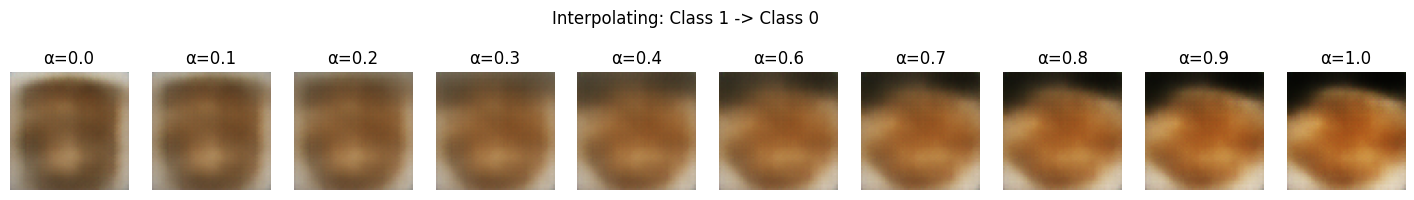

In [ ]:
model.eval()

data_iter = iter(train_loader)
images, labels = next(data_iter)

idx1 = 0
idx2 = 1

while labels[idx1] == labels[idx2]:
    idx2 += 1

img_A = images[idx1].unsqueeze(0).to(device)
img_B = images[idx2].unsqueeze(0).to(device)

with torch.no_grad():
    mu_A, _ = model.encoder(img_A)
    mu_B, _ = model.encoder(img_B)
    
    z_1 = mu_A.squeeze()
    z_2 = mu_B.squeeze()

num_steps = 10
alphas = torch.linspace(0, 1, steps=num_steps).to(device)
z_interpolated = torch.zeros((num_steps, latent_dim)).to(device)

for i, alpha in enumerate(alphas):
    z_interpolated[i] = alpha * z_1 + (1 - alpha) * z_2

with torch.no_grad():
    generated_images = model.decoder(z_interpolated)

fig, axes = plt.subplots(1, num_steps, figsize=(18, 2))
for i in range(num_steps):
    img = generated_images[i].cpu().numpy().transpose(1, 2, 0)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'α={alphas[i].item():.1f}')

plt.suptitle(f"Interpolating: Class {labels[idx1].item()} -> Class {labels[idx2].item()}", y=1.1)
plt.show()

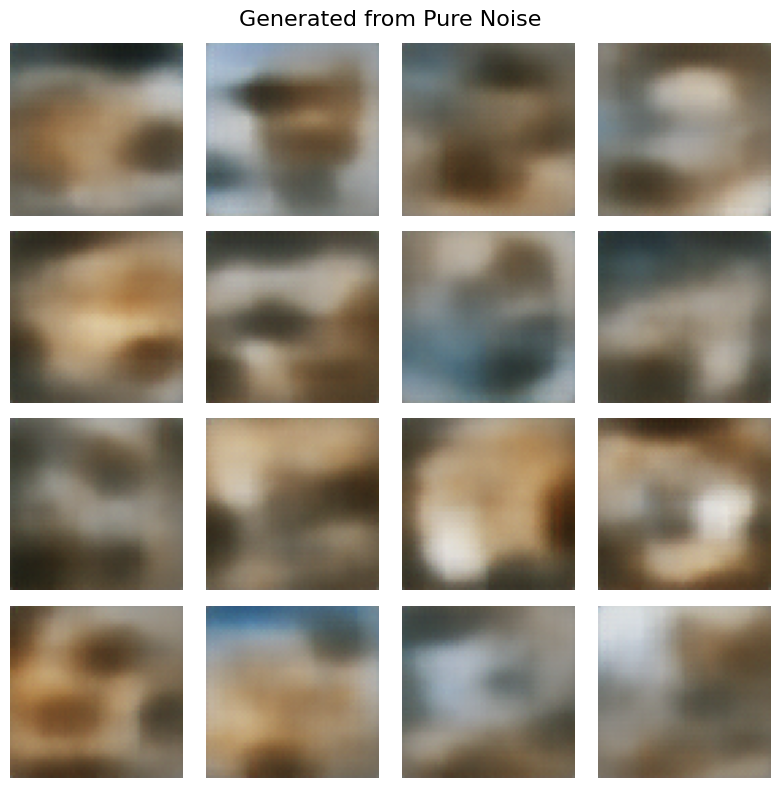

In [ ]:
z_random = torch.randn(16, latent_dim).to(device)

with torch.no_grad():
    fake_images = model.decoder(z_random)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    img = fake_images[i].cpu().numpy().transpose(1, 2, 0)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle("Generated from Pure Noise", fontsize=16)
plt.tight_layout()
plt.show()